# Section 7 - MongoDB Atlas: NoSQL Schema and CRUD Operations

This notebook implements the NorthStar NoSQL design on MongoDB Atlas. It addresses Stage 1 Problem 3 architecturally by embedding complaints inside delivery documents, and Problem 5 architecturally by modelling `app_events` as a flexible-schema collection where structural missingness is natural.

| § | Workflow deliverable | Stage 1 problem |
|---|---|---|
| 7.2 | NoSQL schema design with justification | architectural design |
| 7.3 | Connect to MongoDB Atlas | setup |
| 7.4 | Load cleaned CSVs from GitHub | setup |
| 7.5 | Build documents (Pandas → MongoDB docs) | data preparation |
| 7.6 | Insert documents into Atlas | **Workflow #2** |
| 7.7 | Verify insertion | validation |
| 7.8–7.12 | CRUD: 5 examples each of insert / find / retrieve / update / delete | **Workflow #3** |
| 7.13 | Three plots from MongoDB-extracted data | **Workflow #4** |

## 7.2 : NoSQL Schema Design and Justification

The NorthStar dataset comprises nine relational tables. A literal one-to-one mapping to nine MongoDB collections would miss the architectural opportunity the case study describes namely, resolving the structural fragmentation that prevents NorthStar from producing a unified operational view.

The proposed design uses **six collections** organised around three principles:

1. **Embed when accessed together** : complaints, incidents, and order details are embedded inside delivery documents because every analytical question about a delivery also needs its complaints and incidents (Stage 1 Problem 3).

2. **Reference when shared across many parents** : drivers, vehicles, and hubs are kept as separate collections because each is referenced by hundreds of deliveries; embedding them would duplicate them.

3. **Flexible schema for variable data** : `app_events` is its own collection with no enforced structure, supporting the variable, nested, optionally-order-linked nature of mobile platform events (Stage 1 Problem 5).

| Collection | Documents | Rationale |
|---|---|---|
| `customers` | One per customer (650) | Demographic + loyalty profile; referenced by deliveries |
| `deliveries` | One per delivery (950); embeds order details, complaints array, incidents array | Resolves Problem 3 : complaints surface at delivery row |
| `drivers` | One per driver (170) | Workforce reference; many deliveries reference one driver |
| `vehicles` | One per vehicle (120) | Asset reference; many deliveries reference one vehicle |
| `hubs` | One per hub (8) | Pure reference data |
| `app_events` | One per event (640); flexible schema; optional `order_id` | Resolves Problem 5 : structural missingness is natural |

Database name: `northstar`.

## 7.3 : Connect to MongoDB Atlas

The connection string template is hard-coded in the notebook. The password is loaded from Colab Secrets so it never appears in the notebook file or in the GitHub repository.

In [4]:
# 7.3 : Install PyMongo and connect to Atlas

!pip install pymongo --quiet

from pymongo import MongoClient
from urllib.parse import quote_plus
from google.colab import userdata

# Read password securely from Colab Secrets
password = userdata.get('MONGO_PASSWORD')
encoded_password = quote_plus(password)   # URL-encodes any special characters

USERNAME = "fathimathzahra2023_db_user"
CLUSTER  = "cluster0.ytplja6.mongodb.net"
DB_NAME  = "northstar"

uri = f"mongodb+srv://{USERNAME}:{encoded_password}@{CLUSTER}/?retryWrites=true&w=majority"

client = MongoClient(uri)
db = client[DB_NAME]

# Test the connection
try:
    client.admin.command('ping')
    print(" Connected to MongoDB Atlas")
    print(f" Cluster: {CLUSTER}")
    print(f" Database: {DB_NAME}")
    print(f" Existing collections: {db.list_collection_names()}")
except Exception as e:
    print("Connection failed:")
    print(e)

 Connected to MongoDB Atlas
 Cluster: cluster0.ytplja6.mongodb.net
 Database: northstar
 Existing collections: []


## 7.4 : Load Cleaned CSVs from GitHub

The MongoDB documents are built from the cleaned CSV files persisted by Section 6 (`data/cleaned/` in the repository), not from the raw files. This ensures Atlas receives data that has been zone-standardised, integrity-flagged, and missing-value-handled.

In [5]:
# 7.4 : Load cleaned files from data/cleaned/ on GitHub

import pandas as pd

CLEANED_BASE = "https://raw.githubusercontent.com/fathimathzahrahei/northstar-databases-analytics_dba_coursework/main/data/cleaned/"

clean_files = ['hubs', 'customers', 'drivers', 'vehicles',
               'orders', 'deliveries', 'incidents',
               'complaints', 'app_events']

clean = {}
for name in clean_files:
    clean[name] = pd.read_csv(CLEANED_BASE + name + "_clean.csv")
    print(f"  {name:<12s} loaded: {len(clean[name]):>5} rows")

print("\n All cleaned files loaded from GitHub")

  hubs         loaded:     8 rows
  customers    loaded:   650 rows
  drivers      loaded:   170 rows
  vehicles     loaded:   120 rows
  orders       loaded:  1250 rows
  deliveries   loaded:   950 rows
  incidents    loaded:   280 rows
  complaints   loaded:   320 rows
  app_events   loaded:   640 rows

 All cleaned files loaded from GitHub


## 7.5 : Building Documents (Pandas Rows → MongoDB Documents)

Each Pandas row is transformed into a MongoDB document with the appropriate embedded structure. The `deliveries` collection requires the most work because it embeds order details, complaints array, and incidents array.

In [6]:
# 7.5 : Build all six collection document lists

import math
import numpy as np

def clean_doc(record):
    """Replace NaN with None (MongoDB's null) and convert numpy types to Python types."""
    out = {}
    for k, v in record.items():
        if isinstance(v, float) and math.isnan(v):
            out[k] = None
        elif isinstance(v, (np.integer,)):
            out[k] = int(v)
        elif isinstance(v, (np.floating,)):
            out[k] = float(v)
        elif isinstance(v, (np.bool_,)):
            out[k] = bool(v)
        else:
            out[k] = v
    return out

# === SIMPLE COLLECTIONS (one doc per row) ===
hub_docs      = [clean_doc(r) for r in clean['hubs'].to_dict(orient='records')]
customer_docs = [clean_doc(r) for r in clean['customers'].to_dict(orient='records')]
driver_docs   = [clean_doc(r) for r in clean['drivers'].to_dict(orient='records')]
vehicle_docs  = [clean_doc(r) for r in clean['vehicles'].to_dict(orient='records')]
event_docs    = [clean_doc(r) for r in clean['app_events'].to_dict(orient='records')]

# === DELIVERIES : embed order details, complaints, incidents ===

# Pre-build complaint and incident lookups by their join keys
complaints_by_order = clean['complaints'].groupby('order_id').apply(
    lambda df: [clean_doc(r) for r in df.to_dict(orient='records')]
).to_dict()

incidents_by_delivery = clean['incidents'].groupby('delivery_id').apply(
    lambda df: [clean_doc(r) for r in df.to_dict(orient='records')]
).to_dict()

orders_by_id = clean['orders'].set_index('order_id').to_dict(orient='index')

delivery_docs = []
for r in clean['deliveries'].to_dict(orient='records'):
    doc = clean_doc(r)
    oid = doc['order_id']
    # Embed order details
    if oid in orders_by_id:
        doc['order_details'] = clean_doc(orders_by_id[oid])
    # Embed complaints array
    doc['complaints'] = complaints_by_order.get(oid, [])
    # Embed incidents array
    doc['incidents'] = incidents_by_delivery.get(doc['delivery_id'], [])
    delivery_docs.append(doc)

print(f"Document counts ready for insertion:")
print(f"  hubs:        {len(hub_docs):>5}")
print(f"  customers:   {len(customer_docs):>5}")
print(f"  drivers:     {len(driver_docs):>5}")
print(f"  vehicles:    {len(vehicle_docs):>5}")
print(f"  app_events:  {len(event_docs):>5}")
print(f"  deliveries:  {len(delivery_docs):>5} (with embedded order/complaints/incidents)")

# Show one sample delivery doc to confirm the embedded structure
print("\nSample delivery document (first one):")
import json
sample = {k: v for k, v in delivery_docs[0].items()}
# Truncate the embedded arrays for printing
if isinstance(sample.get('complaints'), list):
    sample['complaints'] = f"[{len(sample['complaints'])} embedded complaint(s)]"
if isinstance(sample.get('incidents'), list):
    sample['incidents'] = f"[{len(sample['incidents'])} embedded incident(s)]"
print(json.dumps(sample, indent=2, default=str))

Document counts ready for insertion:
  hubs:            8
  customers:     650
  drivers:       170
  vehicles:      120
  app_events:    640
  deliveries:    950 (with embedded order/complaints/incidents)

Sample delivery document (first one):
{
  "delivery_id": "DL00001",
  "order_id": "O00938",
  "driver_id": "D004",
  "vehicle_id": "V056",
  "hub_id": "H05",
  "dispatch_time": "2024-06-18 10:57:00",
  "delivery_completed_at": "2024-06-19 09:05:59.904311",
  "delivery_status": "Failed",
  "route_distance_km": 17.26,
  "manual_route_override_count": 1,
  "proof_of_completion_missing": 0,
  "customer_rating_post_delivery": 3.07,
  "fuel_or_charge_cost": 12.05,
  "dispatch_to_completion_minutes": 1328.9984051833335,
  "integrity_flag": "OK",
  "true_outcome": "Failed",
  "order_details": {
    "customer_id": "C0567",
    "service_type": "Business",
    "order_created_at": "2024-06-18 09:48:00",
    "promised_window_hours": 6,
    "pickup_zone": "Central",
    "dropoff_zone": "Central",

/tmp/ipykernel_639/2974556168.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  complaints_by_order = clean['complaints'].groupby('order_id').apply(
/tmp/ipykernel_639/2974556168.py:36: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  incidents_by_delivery = clean['incidents'].groupby('delivery_id').apply(


## 7.6 : Inserting Documents into Atlas

`insert_many` is used because we are loading entire collections at once. Existing collections are dropped first to ensure idempotency: re-running this cell produces the same final state.

In [7]:
# 7.6 : Insert all collections into Atlas (drop-and-reload pattern for idempotency)

collections_to_insert = [
    ('hubs',       hub_docs),
    ('customers',  customer_docs),
    ('drivers',    driver_docs),
    ('vehicles',   vehicle_docs),
    ('app_events', event_docs),
    ('deliveries', delivery_docs),
]

for coll_name, docs in collections_to_insert:
    db[coll_name].drop()
    if docs:
        result = db[coll_name].insert_many(docs)
        print(f"  {coll_name:<12s} inserted: {len(result.inserted_ids):>5} docs")
    else:
        print(f"  {coll_name:<12s} skipped (no docs)")

print("\n All collections loaded into Atlas")

  hubs         inserted:     8 docs
  customers    inserted:   650 docs
  drivers      inserted:   170 docs
  vehicles     inserted:   120 docs
  app_events   inserted:   640 docs
  deliveries   inserted:   950 docs

 All collections loaded into Atlas


## 7.7 : Verifying the Insertion

A simple count per collection confirms the data is in Atlas. The Atlas web UI's *Browse Collections* feature provides a visual cross-check.

In [9]:
# 7.7 : Verify document counts per collection

print("Verification - document counts in Atlas:")
print("-" * 45)
for coll_name in db.list_collection_names():
    count = db[coll_name].count_documents({})
    print(f"  {coll_name:<12s} {count:>5} documents")

# Spot-check: confirm one delivery has its embedded structure
print("\nSpot-check: a delivery with at least one complaint embedded")
sample = db.deliveries.find_one({'complaints': {'$ne': []}})
if sample:
    print(f"  delivery_id:{sample.get('delivery_id')}")
    print(f"  order_id:{sample.get('order_id')}")
    print(f"  delivery_status: {sample.get('delivery_status')}")
    print(f"  embedded complaints:{len(sample.get('complaints', []))}")
    print(f"  embedded incidents:{len(sample.get('incidents', []))}")
    print(f"  has order_details:{'order_details' in sample}")
else:
    print("  (no delivery with embedded complaints found)")

Verification - document counts in Atlas:
---------------------------------------------
  deliveries     950 documents
  drivers        170 documents
  app_events     640 documents
  hubs             8 documents
  vehicles       120 documents
  customers      650 documents

Spot-check: a delivery with at least one complaint embedded
  delivery_id:DL00010
  order_id:O00836
  delivery_status: Failed
  embedded complaints:1
  embedded incidents:0
  has order_details:True


## 7.8 : Five INSERT Operations

Five `insert_one` examples covering different collections and use cases.

In [10]:
# 7.8 : Five INSERT examples

print("=" * 60)
print("INSERT 1: Add a new customer")
print("=" * 60)
new_customer = {
    "customer_id": "C9001",
    "customer_type": "Individual",
    "home_zone": "Central",
    "signup_date": "2026-05-01",
    "loyalty_score": 50.0,
    "preferred_channel": "App",
    "app_engagement_score": 0.65
}
r1 = db.customers.insert_one(new_customer)
print(f"Inserted customer with _id: {r1.inserted_id}")

print("\n" + "=" * 60)
print("INSERT 2: Add a new driver")
print("=" * 60)
new_driver = {
    "driver_id": "DR9001",
    "base_zone": "East",
    "years_experience": 3,
    "training_score": 78.0,
    "active": True
}
r2 = db.drivers.insert_one(new_driver)
print(f"Inserted driver with _id: {r2.inserted_id}")

print("\n" + "=" * 60)
print("INSERT 3: Add a new vehicle")
print("=" * 60)
new_vehicle = {
    "vehicle_id": "V9001",
    "vehicle_type": "EV",
    "assigned_zone": "Riverside",
    "battery_health_pct": 95.0,
    "in_service": True
}
r3 = db.vehicles.insert_one(new_vehicle)
print(f"Inserted vehicle with _id: {r3.inserted_id}")

print("\n" + "=" * 60)
print("INSERT 4: Add an app_event with no order_id (structural NaN)")
print("=" * 60)
new_event = {
    "event_id": "E9001",
    "customer_id": "C9001",
    "event_type": "BrowseService",
    "event_timestamp": "2026-05-08T10:30:00",
    "zone_context": "Central",
    "order_id": None             # event with no order - modelled cleanly in MongoDB
}
r4 = db.app_events.insert_one(new_event)
print(f"Inserted event with _id: {r4.inserted_id}")

print("\n" + "=" * 60)
print("INSERT 5: Push a new complaint into an existing delivery's complaints array")
print("=" * 60)
target_delivery = db.deliveries.find_one({'delivery_status': 'OnTime',
                                           'complaints': []})
if target_delivery:
    new_complaint = {
        "complaint_id": "CMP9001",
        "customer_id": target_delivery['order_details']['customer_id'],
        "order_id":    target_delivery['order_id'],
        "severity": "Medium",
        "complaint_type": "Driver communication",
        "compensation_amount": 5.00,
        "created_at": "2026-05-08T11:00:00"
    }
    r5 = db.deliveries.update_one(
        {'_id': target_delivery['_id']},
        {'$push': {'complaints': new_complaint}}
    )
    print(f"Pushed complaint into delivery {target_delivery['delivery_id']}")
    print(f"Modified count: {r5.modified_count}")
else:
    print("No matching delivery found.")

INSERT 1: Add a new customer
Inserted customer with _id: 6a00c36feca86f8c1569ce61

INSERT 2: Add a new driver
Inserted driver with _id: 6a00c36feca86f8c1569ce62

INSERT 3: Add a new vehicle
Inserted vehicle with _id: 6a00c36feca86f8c1569ce63

INSERT 4: Add an app_event with no order_id (structural NaN)
Inserted event with _id: 6a00c36feca86f8c1569ce64

INSERT 5: Push a new complaint into an existing delivery's complaints array
Pushed complaint into delivery DL00002
Modified count: 1


## 7.9 : Five FIND Operations

Five `find` examples ; simple filter queries that return matching documents.

In [11]:
# 7.9 : Five FIND examples

print("=" * 60)
print("FIND 1: All deliveries flagged TIMESTAMP_IMPOSSIBLE")
print("=" * 60)
f1 = list(db.deliveries.find({'integrity_flag': 'TIMESTAMP_IMPOSSIBLE'},
                              {'_id': 0, 'delivery_id': 1, 'order_id': 1,
                               'delivery_status': 1, 'integrity_flag': 1}))
print(f"Returned {len(f1)} documents. First 3:")
for d in f1[:3]: print(f"  {d}")

print("\n" + "=" * 60)
print("FIND 2: All deliveries with at least one HIGH severity complaint")
print("=" * 60)
f2 = list(db.deliveries.find(
    {'complaints.severity': 'High'},
    {'_id': 0, 'delivery_id': 1, 'delivery_status': 1, 'true_outcome': 1}
).limit(5))
print(f"First 5 of returned documents:")
for d in f2: print(f"  {d}")

print("\n" + "=" * 60)
print("FIND 3: All EV vehicles with battery health > 90%")
print("=" * 60)
f3 = list(db.vehicles.find(
    {'vehicle_type': 'EV', 'battery_health_pct': {'$gt': 90}},
    {'_id': 0, 'vehicle_id': 1, 'assigned_zone': 1, 'battery_health_pct': 1}
).limit(5))
print(f"Found {db.vehicles.count_documents({'vehicle_type':'EV','battery_health_pct':{'$gt':90}})} matching, first 5:")
for d in f3: print(f"  {d}")

print("\n" + "=" * 60)
print("FIND 4: All app_events with NO associated order (structural NaN)")
print("=" * 60)
f4_count = db.app_events.count_documents({'order_id': None})
print(f"Total events with no order_id: {f4_count}")
f4_sample = list(db.app_events.find(
    {'order_id': None},
    {'_id': 0, 'event_id': 1, 'event_type': 1, 'zone_context': 1}
).limit(3))
print("Sample 3:")
for d in f4_sample: print(f"  {d}")

print("\n" + "=" * 60)
print("FIND 5: Customers in Central zone with loyalty_score >= 70")
print("=" * 60)
f5 = list(db.customers.find(
    {'home_zone': 'Central', 'loyalty_score': {'$gte': 70}},
    {'_id': 0, 'customer_id': 1, 'customer_type': 1, 'loyalty_score': 1}
).limit(5))
print(f"First 5 of returned documents:")
for d in f5: print(f"  {d}")

FIND 1: All deliveries flagged TIMESTAMP_IMPOSSIBLE
Returned 64 documents. First 3:
  {'delivery_id': 'DL00002', 'order_id': 'O00004', 'delivery_status': 'OnTime', 'integrity_flag': 'TIMESTAMP_IMPOSSIBLE'}
  {'delivery_id': 'DL00011', 'order_id': 'O00202', 'delivery_status': 'OnTime', 'integrity_flag': 'TIMESTAMP_IMPOSSIBLE'}
  {'delivery_id': 'DL00018', 'order_id': 'O00611', 'delivery_status': 'OnTime', 'integrity_flag': 'TIMESTAMP_IMPOSSIBLE'}

FIND 2: All deliveries with at least one HIGH severity complaint
First 5 of returned documents:
  {'delivery_id': 'DL00010', 'delivery_status': 'Failed', 'true_outcome': 'Failed'}
  {'delivery_id': 'DL00040', 'delivery_status': 'Failed', 'true_outcome': 'Failed'}
  {'delivery_id': 'DL00041', 'delivery_status': 'Failed', 'true_outcome': 'Failed'}
  {'delivery_id': 'DL00047', 'delivery_status': 'OnTime', 'true_outcome': 'OnTime_with_complaint'}
  {'delivery_id': 'DL00063', 'delivery_status': 'OnTime', 'true_outcome': 'OnTime_with_complaint'}

FI

## 7.10 : Five RETRIEVE (Aggregation) Operations

Aggregation pipelines that compute summaries, the document-database equivalent of SQL's `GROUP BY`.

In [14]:
# 7.10 : Five RETRIEVE (aggregation pipeline) examples

print("=" * 60)
print("RETRIEVE 1: Delivery outcome distribution")
print("=" * 60)
r1 = list(db.deliveries.aggregate([
    {'$group': {'_id': '$delivery_status', 'count': {'$sum': 1}}},
    {'$sort': {'count': -1}}
]))
for row in r1: print(f"  {row['_id']:<10s} {row['count']}")

print("\n" + "=" * 60)
print("RETRIEVE 2: Failure rate per pickup zone (using embedded order_details)")
print("=" * 60)
r2 = list(db.deliveries.aggregate([
    {'$group': {
        '_id': '$order_details.pickup_zone',
        'total': {'$sum': 1},
        'failed': {'$sum': {'$cond': [{'$eq': ['$delivery_status', 'Failed']}, 1, 0]}},
        'delayed': {'$sum': {'$cond': [{'$eq': ['$delivery_status', 'Delayed']}, 1, 0]}}
    }},
    {'$project': {
        '_id': 1, 'total': 1, 'failed': 1, 'delayed': 1,
        'fail_or_delay_pct': {'$round': [
            {'$multiply': [{'$divide': [{'$add': ['$failed', '$delayed']}, '$total']}, 100]}, 1
        ]}
    }},
    {'$sort': {'fail_or_delay_pct': -1}}
]))
for row in r2: print(f"  {row}")

print("\n" + "=" * 60)
print("RETRIEVE 3: Top 5 drivers by trip count, with override average")
print("=" * 60)
r3 = list(db.deliveries.aggregate([
    {'$group': {
        '_id': '$driver_id',
        'trips': {'$sum': 1},
        'avg_overrides': {'$avg': '$manual_route_override_count'},
        'ontime': {'$sum': {'$cond': [{'$eq': ['$delivery_status', 'OnTime']}, 1, 0]}}
    }},
    {'$project': {
        '_id': 1, 'trips': 1, 'ontime': 1,
        'avg_overrides': {'$round': ['$avg_overrides', 2]}
    }},
    {'$sort': {'trips': -1}},
    {'$limit': 5}
]))
for row in r3: print(f"  {row}")

print("\n" + "=" * 60)
print("RETRIEVE 4: Total compensation paid per zone (unwinding embedded complaints)")
print("=" * 60)
r4 = list(db.deliveries.aggregate([
    {'$unwind': '$complaints'},
    {'$group': {
        '_id': '$order_details.pickup_zone',
        'complaint_count': {'$sum': 1},
        'total_compensation': {'$sum': '$complaints.compensation_amount'}
    }},
    {'$project': {
        '_id': 1, 'complaint_count': 1,
        'total_compensation': {'$round': ['$total_compensation', 2]}
    }},
    {'$sort': {'total_compensation': -1}}
]))
for row in r4: print(f"  {row}")

print("\n" + "=" * 60)
print("RETRIEVE 5: Hidden complaint signal - OnTime deliveries with HIGH severity complaints")
print("=" * 60)
r5 = list(db.deliveries.aggregate([
    {'$match': {
        'delivery_status': 'OnTime',
        'complaints.severity': 'High'
    }},
    {'$group': {
        '_id': '$order_details.pickup_zone',
        'hidden_failures': {'$sum': 1}
    }},
    {'$sort': {'hidden_failures': -1}}
]))
total_hidden = sum(r['hidden_failures'] for r in r5)
print(f"Total hidden failures (OnTime + High-severity complaint): {total_hidden}")
print("By zone:")
for row in r5: print(f"  {row}")

RETRIEVE 1: Delivery outcome distribution
  OnTime     616
  Delayed    202
  Failed     132

RETRIEVE 2: Failure rate per pickup zone (using embedded order_details)
  {'_id': 'Central', 'total': 174, 'failed': 33, 'delayed': 51, 'fail_or_delay_pct': 48.3}
  {'_id': 'Airport', 'total': 113, 'failed': 12, 'delayed': 31, 'fail_or_delay_pct': 38.1}
  {'_id': 'Riverside', 'total': 119, 'failed': 18, 'delayed': 25, 'fail_or_delay_pct': 36.1}
  {'_id': 'East', 'total': 156, 'failed': 19, 'delayed': 31, 'fail_or_delay_pct': 32.1}
  {'_id': 'North', 'total': 135, 'failed': 22, 'delayed': 21, 'fail_or_delay_pct': 31.9}
  {'_id': 'West', 'total': 114, 'failed': 14, 'delayed': 21, 'fail_or_delay_pct': 30.7}
  {'_id': 'South', 'total': 139, 'failed': 14, 'delayed': 22, 'fail_or_delay_pct': 25.9}

RETRIEVE 3: Top 5 drivers by trip count, with override average
  {'_id': 'D102', 'trips': 13, 'ontime': 12, 'avg_overrides': 0.38}
  {'_id': 'D133', 'trips': 12, 'ontime': 6, 'avg_overrides': 0.92}
  {'_i

## 7.11 : Five UPDATE Operations

In [15]:
# 7.11 : Five UPDATE examples

print("=" * 60)
print("UPDATE 1: Increase loyalty_score by 10 for our test customer")
print("=" * 60)
u1 = db.customers.update_one(
    {'customer_id': 'C9001'},
    {'$inc': {'loyalty_score': 10}}
)
print(f"Matched: {u1.matched_count}, Modified: {u1.modified_count}")
print(f"After:    {db.customers.find_one({'customer_id':'C9001'}, {'_id':0,'loyalty_score':1})}")

print("\n" + "=" * 60)
print("UPDATE 2: Mark all deliveries with TIMESTAMP_IMPOSSIBLE as needing review")
print("=" * 60)
u2 = db.deliveries.update_many(
    {'integrity_flag': 'TIMESTAMP_IMPOSSIBLE'},
    {'$set': {'needs_data_quality_review': True}}
)
print(f"Modified {u2.modified_count} deliveries")

print("\n" + "=" * 60)
print("UPDATE 3: Set vehicle V9001 out of service")
print("=" * 60)
u3 = db.vehicles.update_one(
    {'vehicle_id': 'V9001'},
    {'$set': {'in_service': False, 'reason': 'Annual maintenance'}}
)
print(f"Matched: {u3.matched_count}, Modified: {u3.modified_count}")

print("\n" + "=" * 60)
print("UPDATE 4: Increment compensation by £5 for one specific complaint inside an array")
print("=" * 60)
target = db.deliveries.find_one({'complaints.complaint_id': 'CMP9001'})
if target:
    u4 = db.deliveries.update_one(
        {'_id': target['_id'], 'complaints.complaint_id': 'CMP9001'},
        {'$inc': {'complaints.$.compensation_amount': 5.00}}
    )
    print(f"Modified array element. Matched: {u4.matched_count}")
else:
    print("CMP9001 not found , was INSERT 5 run successfully?")

print("\n" + "=" * 60)
print("UPDATE 5: Bulk update flag long-haul deliveries (route > 30 km) for review")
print("=" * 60)
u5 = db.deliveries.update_many(
    {'route_distance_km': {'$gt': 30}},
    {'$set': {'long_haul': True}}
)
print(f"Modified {u5.modified_count} deliveries flagged as long-haul")

UPDATE 1: Increase loyalty_score by 10 for our test customer
Matched: 1, Modified: 1
After:    {'loyalty_score': 60.0}

UPDATE 2: Mark all deliveries with TIMESTAMP_IMPOSSIBLE as needing review
Modified 64 deliveries

UPDATE 3: Set vehicle V9001 out of service
Matched: 1, Modified: 1

UPDATE 4: Increment compensation by £5 for one specific complaint inside an array
Modified array element. Matched: 1

UPDATE 5: Bulk update flag long-haul deliveries (route > 30 km) for review
Modified 49 deliveries flagged as long-haul


## 7.12 : Five DELETE Operations

In [16]:
# 7.12 : Five DELETE examples

print("=" * 60)
print("DELETE 1: Remove the test customer")
print("=" * 60)
d1 = db.customers.delete_one({'customer_id': 'C9001'})
print(f"Deleted count: {d1.deleted_count}")

print("\n" + "=" * 60)
print("DELETE 2: Remove the test driver")
print("=" * 60)
d2 = db.drivers.delete_one({'driver_id': 'DR9001'})
print(f"Deleted count: {d2.deleted_count}")

print("\n" + "=" * 60)
print("DELETE 3: Remove the test vehicle")
print("=" * 60)
d3 = db.vehicles.delete_one({'vehicle_id': 'V9001'})
print(f"Deleted count: {d3.deleted_count}")

print("\n" + "=" * 60)
print("DELETE 4: Remove the test event")
print("=" * 60)
d4 = db.app_events.delete_one({'event_id': 'E9001'})
print(f"Deleted count: {d4.deleted_count}")

print("\n" + "=" * 60)
print("DELETE 5: Pull the test complaint out of the delivery's array")
print("=" * 60)
d5 = db.deliveries.update_one(
    {'complaints.complaint_id': 'CMP9001'},
    {'$pull': {'complaints': {'complaint_id': 'CMP9001'}}}
)
print(f"Pulled from array. Modified: {d5.modified_count}")

print("\n" + "=" * 60)
print("CLEANUP: Restore long_haul flag (revert UPDATE 5)")
print("=" * 60)
cleanup = db.deliveries.update_many(
    {'long_haul': True},
    {'$unset': {'long_haul': ''}}
)
print(f"Reverted {cleanup.modified_count} deliveries")

DELETE 1: Remove the test customer
Deleted count: 1

DELETE 2: Remove the test driver
Deleted count: 1

DELETE 3: Remove the test vehicle
Deleted count: 1

DELETE 4: Remove the test event
Deleted count: 1

DELETE 5: Pull the test complaint out of the delivery's array
Pulled from array. Modified: 1

CLEANUP: Restore long_haul flag (revert UPDATE 5)
Reverted 49 deliveries


## 7.13 : Three Plots from MongoDB-Extracted Data

Three plots produced from data pulled directly out of MongoDB through aggregation pipelines, demonstrating that visualisation can sit on top of NoSQL queries just as easily as on top of SQL.

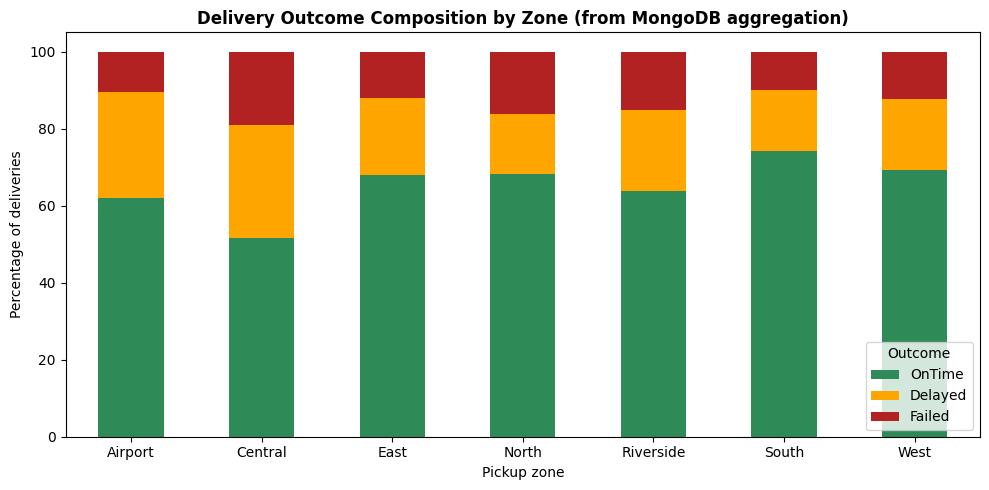

In [17]:
# 7.13 a) Plot 1: outcome distribution by zone (from aggregation pipeline)

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

pipeline = [
    {'$group': {
        '_id': {'zone': '$order_details.pickup_zone', 'status': '$delivery_status'},
        'count': {'$sum': 1}
    }}
]

raw = list(db.deliveries.aggregate(pipeline))
df_plot = pd.DataFrame([{
    'zone':   r['_id']['zone'],
    'status': r['_id']['status'],
    'count':  r['count']
} for r in raw if r['_id']['zone'] is not None])

pivot = df_plot.pivot(index='zone', columns='status', values='count').fillna(0)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

plt.figure(figsize=(10, 5))
pivot_pct[['OnTime','Delayed','Failed']].plot(
    kind='bar', stacked=True,
    color=['#2E8B57','#FFA500','#B22222'], ax=plt.gca()
)
plt.title('Delivery Outcome Composition by Zone (from MongoDB aggregation)',
          fontweight='bold')
plt.xlabel('Pickup zone')
plt.ylabel('Percentage of deliveries')
plt.legend(title='Outcome', loc='lower right')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('plot_mongo_zone.png', dpi=150, bbox_inches='tight')
plt.show()

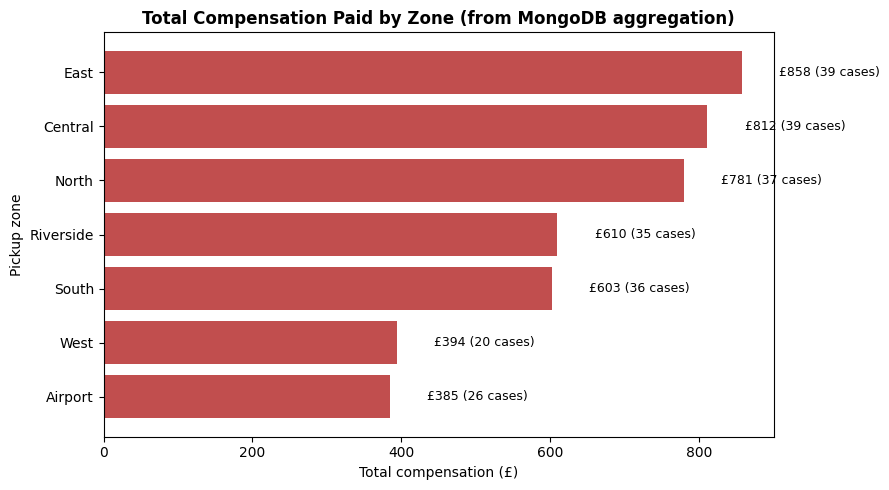

In [18]:
# 7.13 b) Plot 2: total compensation by zone (from $unwind pipeline)

pipeline = [
    {'$unwind': '$complaints'},
    {'$group': {
        '_id': '$order_details.pickup_zone',
        'total_comp': {'$sum': '$complaints.compensation_amount'},
        'complaint_count': {'$sum': 1}
    }}
]

raw = list(db.deliveries.aggregate(pipeline))
df_plot = pd.DataFrame([{
    'zone': r['_id'], 'total_comp': r['total_comp'], 'count': r['complaint_count']
} for r in raw if r['_id'] is not None]).sort_values('total_comp', ascending=True)

plt.figure(figsize=(9, 5))
plt.barh(df_plot['zone'], df_plot['total_comp'], color='#B22222', alpha=0.8)
for i, (zone, total, count) in enumerate(zip(df_plot['zone'], df_plot['total_comp'], df_plot['count'])):
    plt.text(total + 50, i, f'£{total:.0f} ({count} cases)', va='center', fontsize=9)
plt.title('Total Compensation Paid by Zone (from MongoDB aggregation)',
          fontweight='bold')
plt.xlabel('Total compensation (£)')
plt.ylabel('Pickup zone')
plt.tight_layout()
plt.savefig('plot_mongo_compensation.png', dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_639/3209068029.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='vehicle_type', y='battery_health_pct',


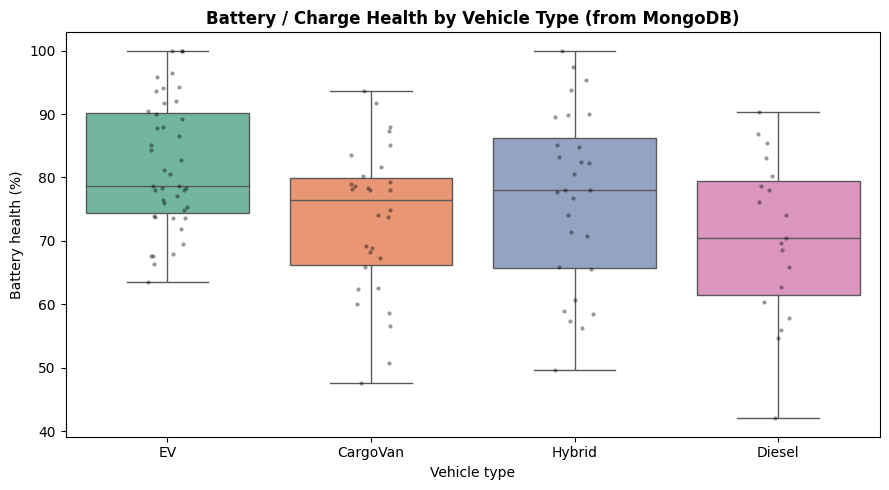

In [19]:
# 7.13 c) Plot 3: battery health distribution by vehicle type

vehicles_data = list(db.vehicles.find({}, {'_id': 0, 'vehicle_type': 1, 'battery_health_pct': 1}))
df_plot = pd.DataFrame(vehicles_data).dropna()

plt.figure(figsize=(9, 5))
sns.boxplot(data=df_plot, x='vehicle_type', y='battery_health_pct',
            palette='Set2')
sns.stripplot(data=df_plot, x='vehicle_type', y='battery_health_pct',
              color='black', alpha=0.4, size=3)
plt.title('Battery / Charge Health by Vehicle Type (from MongoDB)',
          fontweight='bold')
plt.xlabel('Vehicle type')
plt.ylabel('Battery health (%)')
plt.tight_layout()
plt.savefig('plot_mongo_battery.png', dpi=150, bbox_inches='tight')
plt.show()

## Section Summary

This notebook implemented the NorthStar NoSQL design on MongoDB Atlas:

- **Schema design** : 6 collections, with deliveries embedding order details, complaints, and incidents to resolve Stage 1 Problem 3 architecturally
- **Data insertion** : all cleaned data loaded with idempotent drop-and-reload pattern
- **CRUD operations** : 5 examples each of insert / find / retrieve (aggregation) / update / delete = **25 demonstrations**
- **Three plots** produced from MongoDB aggregation pipelines, not from the raw CSVs

The design is queried in Section 8, where indexing strategies and explain-plan analysis quantify the performance impact of design choices.

Notebook: `notebooks/04_mongodb_design.ipynb`.